# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv('boston_house_prices.csv')

In [30]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [31]:
X = df.drop('MEDV',axis=1)
y = df['MEDV']

### 1. Data Preparation

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
model_LR = LinearRegression()

In [36]:
model_LR.fit(X_train,y_train)

LinearRegression()

In [37]:
model_LR.coef_

array([-8.85049752e-02,  5.02928536e-02,  2.03483110e-02,  3.75427054e+00,
       -1.77483714e+01,  3.24776492e+00,  1.20008182e-02, -1.40916141e+00,
        2.63880691e-01, -1.03440009e-02, -9.51780874e-01,  6.11600491e-03,
       -5.97133217e-01])

In [38]:
pd.Series(model_LR.coef_, index=X.columns)

CRIM       -0.088505
ZN          0.050293
INDUS       0.020348
CHAS        3.754271
NOX       -17.748371
RM          3.247765
AGE         0.012001
DIS        -1.409161
RAD         0.263881
TAX        -0.010344
PTRATIO    -0.951781
B           0.006116
LSTAT      -0.597133
dtype: float64

In [39]:
model_LR.intercept_

np.float64(40.21892901255097)

In [40]:
test_predictions = model_LR.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [42]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [43]:
print(MAE, MSE, RMSE)

3.835696361418934 28.547585271468137 5.34299403625609


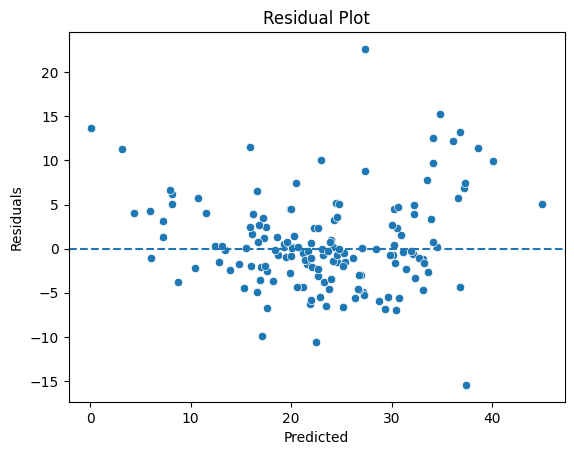

In [44]:
residuals = y_test - test_predictions

sns.scatterplot(x=test_predictions, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [45]:
from sklearn.preprocessing import PolynomialFeatures

In [46]:
polynomial_converter = PolynomialFeatures(degree=2)

In [47]:
# Converter "fits" to data, in this case, reads in every X column
# Then it "transforms" and ouputs the new polynomial data
poly_features = polynomial_converter.fit_transform(X)

In [48]:
from sklearn.linear_model import LinearRegression
model_PR= LinearRegression()

In [49]:
model_PR.fit(X_train,y_train)

LinearRegression()

In [50]:
test_predictions_PR = model_PR.predict(X_test)

In [54]:
MAE_PR = mean_absolute_error(y_test,test_predictions_PR)
MSE_PR = mean_squared_error(y_test,test_predictions_PR)
RMSE_PR = np.sqrt(MSE_PR)


print(f"MAE: {MAE_PR}")
print(f"MSE: {MSE_PR}")
print(f"RMSE: {RMSE_PR}")

MAE: 3.835696361418934
MSE: 28.547585271468137
RMSE: 5.34299403625609


### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


* Simple Linear Regression:
    * MAE: 3.835696361418934
    * RMSE: 5.34299403625609

* Polynomial 2-degree:
    * MAE: 3.835696361418934
    * RMSE: 5.34299403625609

In [55]:
# TRAINING ERROR PER DEGREE
train_rmse_errors = []
# TEST ERROR PER DEGREE
test_rmse_errors = []

for d in range(1,10):

    # CREATE POLY DATA SET FOR DEGREE "d"
    polynomial_converter = PolynomialFeatures(degree=d)
    poly_features = polynomial_converter.fit_transform(X)

    # SPLIT THIS NEW POLY DATA SET
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

    # TRAIN ON THIS NEW POLY SET
    model = LinearRegression()
    model.fit(X_train,y_train)

    # PREDICT ON BOTH TRAIN AND TEST
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate Errors

    # Errors on Train Set
    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))

    # Errors on Test Set
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

    # Append errors to lists for plotting later


    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

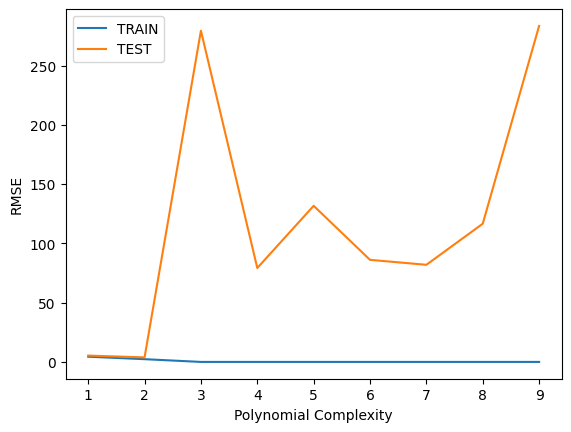

In [56]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

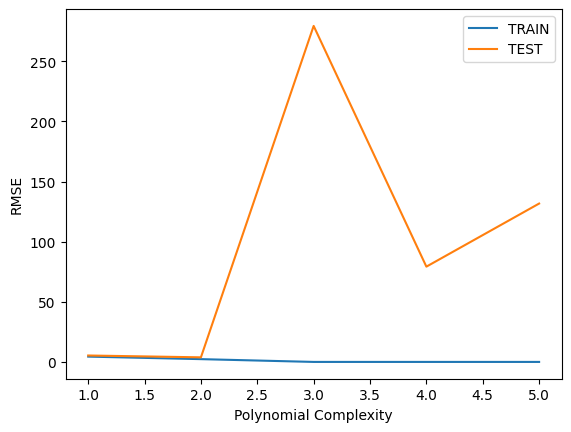

In [57]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

In [58]:
final_poly_converter = PolynomialFeatures(degree=4,include_bias=False)

In [59]:
final_model = LinearRegression()

In [60]:
final_model.fit(final_poly_converter.fit_transform(X),y)

LinearRegression()